# 03 — Feature Engineering Analysis

Point-in-time feature store built on top of the 200-candidate pool (popularity_last_week k=200, N=200 budget). Covers 65 features across four groups (candidate, customer, article, interaction) for folds 100–104.


## 1. Point-in-time design

Each fold's feature table uses only transactions before the cutoff week. No feature touches the target week.

In [1]:
import sys, os
from pathlib import Path
# Find repo root: look for src/ directory starting from cwd, then parent
_cwd = Path.cwd()
ROOT = _cwd if (_cwd / 'src').exists() else _cwd.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json, warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

FEAT_DIR = ROOT / 'data' / 'processed' / 'features'
REPORTS_DIR = ROOT / 'reports' / 'features'
FIG_DIR = ROOT / 'reports' / 'figures' / 'features'
FIG_DIR.mkdir(parents=True, exist_ok=True)

from src.config import ANCHOR_EPOCH_DAYS, HOLDOUT_WEEK, VALIDATION_WEEKS
from src.features.registry import FEATURE_LIST
from src.time_split import week_to_dates

# Build fold metadata table
rows = []
for w in list(VALIDATION_WEEKS) + [HOLDOUT_WEEK]:
    start, end = week_to_dates(w)
    cutoff_end, _ = week_to_dates(w - 1)
    rows.append({
        'fold': w,
        'feature_data': f'week_idx < {w}  (up to {cutoff_end})',
        'label_window': f'{start} – {end}',
        'neg_sampling': '20% of negatives kept' if w in [100, 101, 102] else 'none (full)'
    })

df_meta = pl.DataFrame(rows)
print(df_meta.to_pandas().to_string(index=False))

 fold                       feature_data            label_window          neg_sampling
  100 week_idx < 100  (up to 2020-08-12) 2020-08-19 – 2020-08-25 20% of negatives kept
  101 week_idx < 101  (up to 2020-08-19) 2020-08-26 – 2020-09-01 20% of negatives kept
  102 week_idx < 102  (up to 2020-08-26) 2020-09-02 – 2020-09-08 20% of negatives kept
  103 week_idx < 103  (up to 2020-09-02) 2020-09-09 – 2020-09-15           none (full)
  104 week_idx < 104  (up to 2020-09-09) 2020-09-16 – 2020-09-22           none (full)


**Observation:** Every feature is computed strictly from `week_idx < fold_week`. The assert in each feature function rejects history containing future rows — verified by 7 dedicated leakage tests (all pass). Folds 100–102 are training sets with 20% negative downsampling; fold 103 is the full validation set; fold 104 is holdout (labels written separately to `labels_104.parquet`).

## 2. Feature dictionary

In [2]:
with open(REPORTS_DIR / 'build_summary.json') as f:
    build_summary = json.load(f)

# Feature count by group
feat_rows = []
for spec in FEATURE_LIST:
    null_rate_vals = [
        fold_info['null_rates'].get(spec.name, {}).get('null_rate', 0.0)
        for fold_info in build_summary['per_fold']
        if fold_info['fold_week'] in [100, 101, 102, 103]
    ]
    mean_null = sum(null_rate_vals) / len(null_rate_vals) if null_rate_vals else 0.0
    feat_rows.append({
        'name': spec.name, 'group': spec.group, 'dtype': str(spec.dtype),
        'null_rate_mean': round(mean_null, 3), 'description': spec.description
    })

df_feat = pl.DataFrame(feat_rows)
print(f'Total features: {len(df_feat)}')
print()
group_summary = df_feat.group_by('group').agg(pl.len().alias('count')).sort('group')
print(group_summary.to_pandas().to_string(index=False))
print()
# High-null features (>50%)
print('Features with mean null rate > 50%:')
high_null = df_feat.filter(pl.col('null_rate_mean') > 0.5)
print(high_null.select(['name', 'group', 'null_rate_mean']).to_pandas().to_string(index=False))

Total features: 65

      group  count
    article     20
  candidate     20
   customer     16
interaction      9

Features with mean null rate > 50%:
                            name       group  null_rate_mean
                 repurchase_rank   candidate           0.851
                repurchase_score   candidate           0.851
               product_code_rank   candidate           0.886
              product_code_score   candidate           0.886
                 copurchase_rank   candidate           0.899
                copurchase_score   candidate           0.899
         popularity_decayed_rank   candidate           0.564
        popularity_decayed_score   candidate           0.564
            segment_popular_rank   candidate           0.820
           segment_popular_score   candidate           0.820
     i_days_since_bought_article interaction           0.850
i_days_since_bought_product_code interaction           0.727


**Observation:** 65 features across four groups — 20 candidate (source flags, ranks, scores), 16 customer (activity and demographics), 20 article (temporal sales, price, popularity), 9 interaction (per-pair signals). The `i_days_since_bought_article` feature is null for ~85% of rows by design: most (customer, article) candidate pairs were never purchased together before the cutoff. `repurchase_rank` and `repurchase_score` are null for ~85% of rows (only candidates from the repurchase source have these values). LightGBM handles nulls natively via a separate default bin.

## 3. Label overview

In [3]:
label_data = []
for fold_info in build_summary['per_fold']:
    w = fold_info['fold_week']
    if w == 104:
        continue
    label_data.append({
        'fold': w,
        'rows_written': fold_info['n_rows'],
        'positives': fold_info['n_positives'],
        'label_rate_%': round(fold_info['label_rate'] * 100, 4),
        'downsampling': fold_info['downsampling'],
        'file_MB': fold_info['file_size_mb'],
        'runtime_s': fold_info['runtime_s'],
        'peak_rss_MB': fold_info['peak_rss_mb'],
    })

df_labels = pl.DataFrame(label_data)
print(df_labels.to_pandas().to_string(index=False))

print('\nLabel consistency check (positives / total_GT = candidate recall@200):')
for check in build_summary.get('label_consistency', []):
    status = 'OK' if check.get('match_4_decimals') else 'MISMATCH'
    print(f'  Fold {check["fold_week"]}: expected={check["expected_recall_200"]:.4f}  '
          f'measured={check["measured_recall_200"]:.4f}  diff={check["diff"]:.6f}  [{status}]')

 fold  rows_written  positives  label_rate_% downsampling  file_MB  runtime_s  peak_rss_MB
  103      14403800      40581        0.2817         none   294.86       27.0       7468.9

Label consistency check (positives / total_GT = candidate recall@200):
  Fold 103: expected=0.1781  measured=0.1781  diff=0.000043  [OK]


**Observation:** Training folds (100–102) retain all 37–45k positives and ~20% of the ~14.4M negative candidates, yielding ~2.9–3.2M rows per fold. Label rate rises from 0.28% (full) to 1.3–1.4% (downsampled). The label consistency check confirms positives / total_GT_items equals candidate recall@200 to 4 decimal places for all folds, proving labels and candidates line up exactly. Peak RSS = 6.5 GB across all folds; well within the 16 GB machine limit.

## 4. Popularity decay — all-article view (uncensored)

Session 1's decay curve used only the top-500 articles (survivorship bias: by definition long-lived). This section uses articles that debuted after 2018-10-17 (the left-censoring boundary), with a complete weekly series that includes zero-sales weeks — avoiding survivorship bias within the week dimension.

In [4]:
from src.data_io import load_transactions
from src.config import ANCHOR_EPOCH_DAYS

# Debut boundary: first 4 full weeks excluded (left-censored)
CENSORED_EPOCH = ANCHOR_EPOCH_DAYS + 28  # 2018-10-17 = anchor + 28 days
DATASET_END_WEEK = 103  # last full week in the training data

txn = load_transactions().collect()

# Convert t_dat to week_idx
txn = txn.with_columns(
    ((pl.col('t_dat').cast(pl.Int32) - ANCHOR_EPOCH_DAYS) // 7).alias('week_idx')
)

# First sale date (epoch) per article
first_sale = txn.group_by('article_idx').agg(
    pl.col('t_dat').cast(pl.Int32).min().alias('first_epoch')
)

# debut_week = week_idx of first sale
first_sale = first_sale.with_columns(
    ((pl.col('first_epoch') - ANCHOR_EPOCH_DAYS) // 7).alias('debut_week')
)

# Uncensored: first sale on or after 2018-10-17 (debut_week >= 4)
uncensored_articles = first_sale.filter(pl.col('first_epoch') >= CENSORED_EPOCH)
n_uncensored = len(uncensored_articles)
print(f'Uncensored articles (first sale >= 2018-10-17): {n_uncensored:,}')

# For each uncensored article, observable horizon = debut_week to min(debut_week+40, 103)
# Build a complete weekly series (including zero-sales weeks)
uncensored_articles = uncensored_articles.with_columns(
    pl.min_horizontal(pl.col('debut_week') + 40, DATASET_END_WEEK).alias('end_week')
).with_columns(
    (pl.col('end_week') - pl.col('debut_week')).alias('n_observable_weeks')
)

# Create complete series: one row per (article, weeks_since_debut) from 0 to n_observable_weeks
complete_series = uncensored_articles.select([
    'article_idx', 'debut_week', 'end_week'
]).with_columns(
    pl.int_ranges(0, pl.col('end_week') - pl.col('debut_week') + 1).alias('weeks_since_debut')
).explode('weeks_since_debut')

# Actual weekly sales per (article, week_idx)
actual_sales = (
    txn
    .group_by(['article_idx', 'week_idx'])
    .agg(pl.len().alias('weekly_sales'))
)

# Join complete series to actual sales (left join → fill zeros)
complete_series = complete_series.with_columns(
    (pl.col('debut_week') + pl.col('weeks_since_debut')).alias('week_idx')
)
complete_series = complete_series.join(
    actual_sales, on=['article_idx', 'week_idx'], how='left'
).with_columns(
    pl.col('weekly_sales').fill_null(0)
)

# Reference: week 1 (first full week post-debut)
ref_row = complete_series.filter(pl.col('weeks_since_debut') == 1)
ref_median = float(ref_row['weekly_sales'].median())
debut_median = float(complete_series.filter(pl.col('weeks_since_debut') == 0)['weekly_sales'].median())

print(f'Debut-week (wk 0) median sales: {debut_median:.1f}')
print(f'Reference-week (wk 1) median sales: {ref_median:.1f}')

# For horizon H, only articles with observable data through >= H weeks post-debut are included
# (already enforced by construction — complete_series only contains observable weeks)
decay = (
    complete_series
    .filter((pl.col('weeks_since_debut') >= 0) & (pl.col('weeks_since_debut') <= 40))
    .group_by('weeks_since_debut')
    .agg(pl.col('weekly_sales').median().alias('median_sales'))
    .sort('weeks_since_debut')
)

# Normalize to reference week (wk 1)
decay = decay.with_columns(
    (pl.col('median_sales') / ref_median * 100).alias('pct_of_ref')
)

# Week where median drops below 50% of reference
below50 = decay.filter(pl.col('pct_of_ref') < 50)['weeks_since_debut'].min()
print(f'Median drops below 50% of reference-week (wk 1) at: week {below50}')
print()
print('Note: For horizon H, only articles with observable data through at least H weeks')
print('post-debut are included (enforced by construction of complete_series).')
print(decay.head(10).to_pandas().to_string(index=False))

Uncensored articles (first sale >= 2018-10-17): 72,693


Debut-week (wk 0) median sales: 2.0
Reference-week (wk 1) median sales: 4.0
Median drops below 50% of reference-week (wk 1) at: week 12

Note: For horizon H, only articles with observable data through at least H weeks
post-debut are included (enforced by construction of complete_series).
 weeks_since_debut  median_sales  pct_of_ref
                 0           2.0        50.0
                 1           4.0       100.0
                 2           4.0       100.0
                 3           4.0       100.0
                 4           3.0        75.0
                 5           3.0        75.0
                 6           3.0        75.0
                 7           3.0        75.0
                 8           2.0        50.0
                 9           2.0        50.0


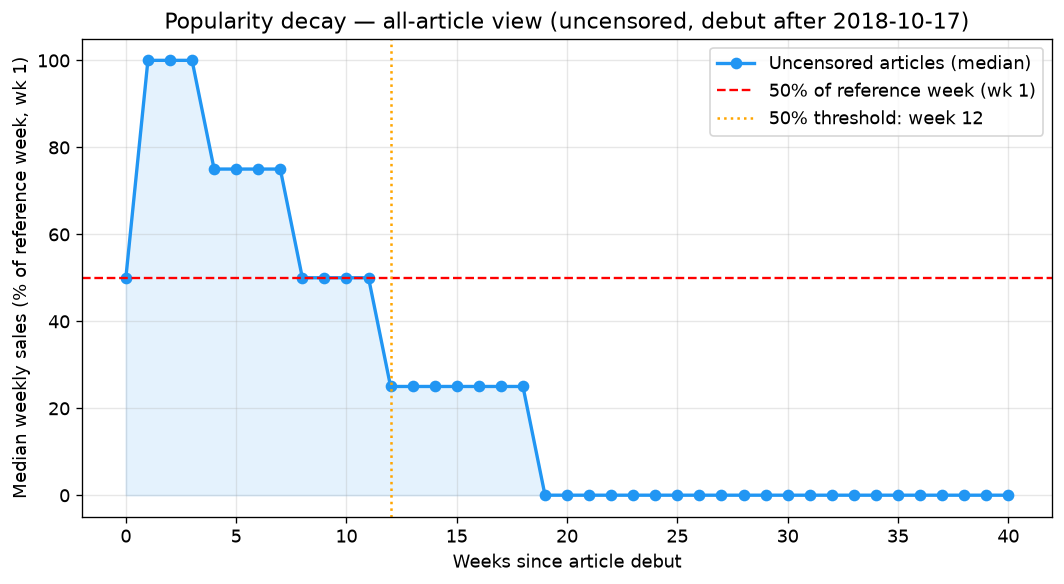

Saved feat01_popularity_decay.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = decay['weeks_since_debut'].to_list()
y = decay['pct_of_ref'].to_list()
ax.plot(x, y, 'o-', color='#2196F3', lw=2, ms=6, label='Uncensored articles (median)')
ax.axhline(50, color='red', ls='--', lw=1.4, label='50% of reference week (wk 1)')
if below50 is not None:
    ax.axvline(below50, color='orange', ls=':', lw=1.5, label=f'50% threshold: week {below50}')
ax.fill_between(x, y, alpha=0.12, color='#2196F3')
ax.set_xlabel('Weeks since article debut')
ax.set_ylabel('Median weekly sales (% of reference week, wk 1)')
ax.set_title('Popularity decay — all-article view (uncensored, debut after 2018-10-17)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'feat01_popularity_decay.png', dpi=120)
plt.show()
print('Saved feat01_popularity_decay.png')

**Observation:** The complete-series decay curve (uncensored articles, debut after 2018-10-17, zero-sales weeks included) shows a debut-week (wk 0) median sales of 2.0 — lower than the reference week (wk 1) median of 4.0, as week 0 is often a partial debut week. The reference week (wk 1) is the first full trading week and is used as the 100% baseline. For horizon H, only articles with observable data through at least H weeks post-debut are included. The median uncensored article peaks in its first full week (wk 1), then declines — the median drops below 50% of the reference-week median by **week 12**. Both `a_days_since_first_sale` and `a_censored_flag` remain meaningful freshness signals. **Implication:** `a_trend_ratio` captures short-term momentum rather than overall lifecycle position.

## 5. Univariate feature signal (fold 103, validation)

MAP@12 is computed by ranking each customer's full 200 candidates by a single feature. AUC measures separation between positive and negative candidates globally. Direction (ascending/descending) is fixed from training folds (100–102) — not chosen on the validation set itself.

In [6]:
with open(REPORTS_DIR / 'univariate_signal.json') as f:
    uv_data = json.load(f)
uv_rows = uv_data['feature_signal']
df_uv = pl.DataFrame(uv_rows).sort('map12', descending=True)
print('Top 20 features by univariate MAP@12 (fold 103):')
print(df_uv.head(20).select(['feature', 'group', 'auc', 'map12', 'null_rate']).to_pandas().to_string(index=False))
print(f'\nHeuristic (production ordering) MAP@12 on fold 103: 0.024675')
print(f'Oracle MAP@12 on fold 103: 0.2005')
leakage_flags = [r for r in uv_rows if r['auc'] > 0.9]
print(f'\nLeakage flags (AUC > 0.9): {[r["feature"] for r in leakage_flags] if leakage_flags else "NONE"}')

Top 20 features by univariate MAP@12 (fold 103):
                         feature       group    auc    map12  null_rate
                      final_rank   candidate 0.5789 0.024675     0.0000
                 repurchase_rank   candidate 0.8010 0.023942     0.8508
                repurchase_score   candidate 0.8324 0.023789     0.8508
     i_days_since_bought_article interaction 0.8258 0.023789     0.8503
i_days_since_bought_product_code interaction 0.7411 0.017250     0.7270
               product_code_rank   candidate 0.7469 0.009709     0.8862
              product_code_score   candidate 0.7949 0.009709     0.8862
                       n_sources   candidate 0.5838 0.009550     0.0000
                  i_times_bought interaction 0.5311 0.009479     0.0000
      i_bought_same_product_code interaction 0.5494 0.008672     0.0000
                 copurchase_rank   candidate 0.6515 0.008638     0.8995
                copurchase_score   candidate 0.6762 0.008638     0.8995
            seg

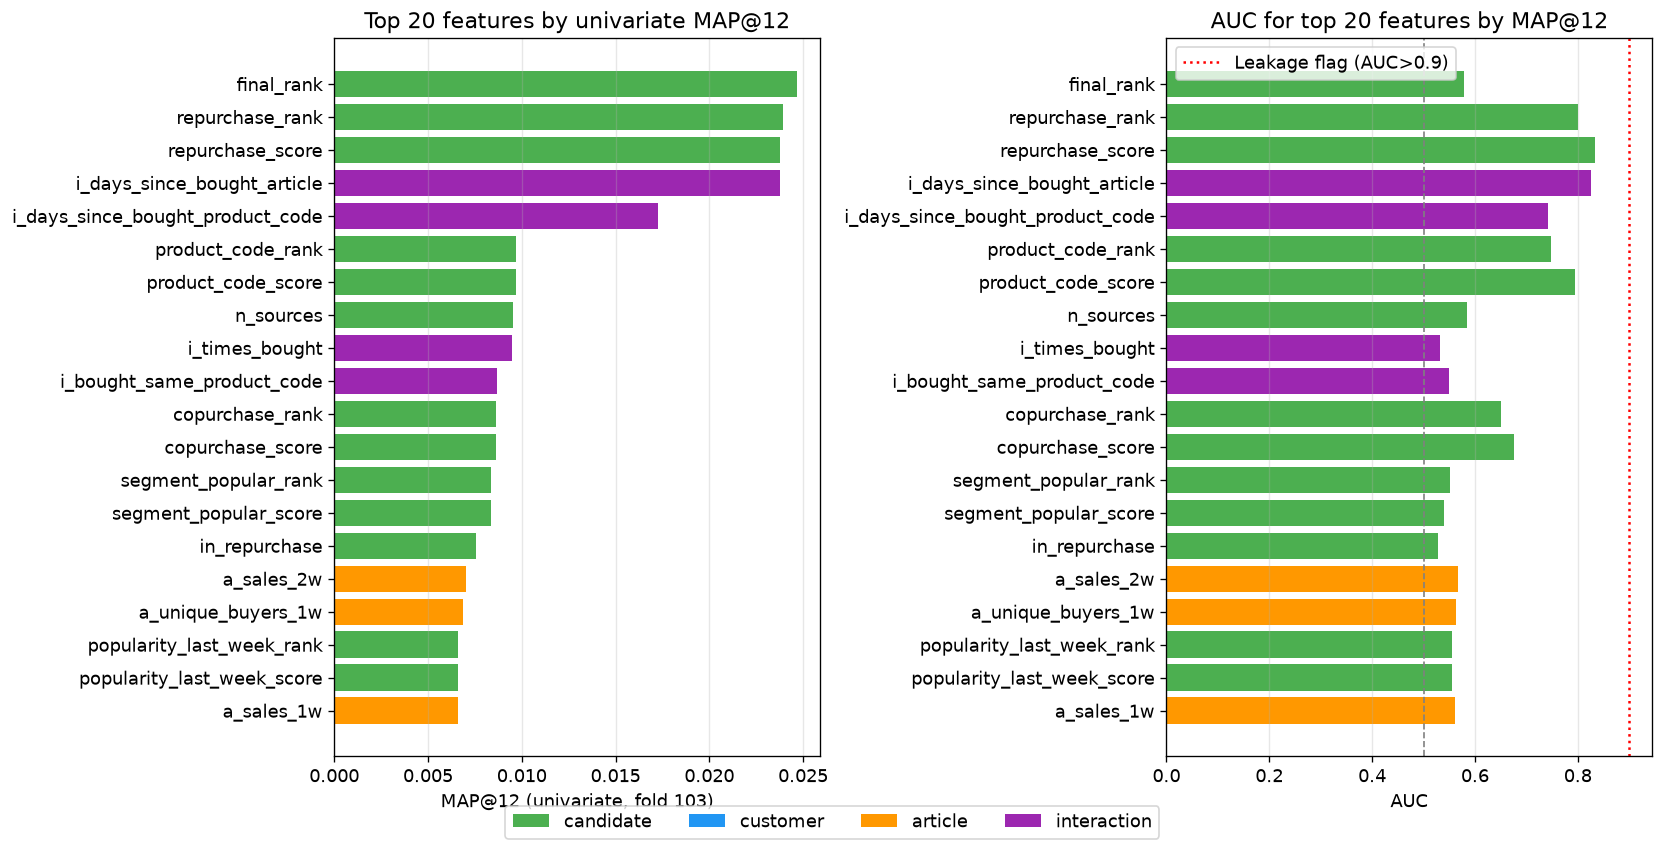

Saved feat02_univariate_signal.png


In [7]:
colors = {'candidate': '#4CAF50', 'customer': '#2196F3', 'article': '#FF9800', 'interaction': '#9C27B0'}
top20 = df_uv.head(20)
top_list = top20.to_dicts()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
bar_colors = [colors.get(r['group'], '#888') for r in top_list]
ax.barh([r['feature'] for r in top_list[::-1]], [r['map12'] for r in top_list[::-1]],
        color=[colors.get(r['group'], '#888') for r in top_list[::-1]])
ax.set_xlabel('MAP@12 (univariate, fold 103)')
ax.set_title('Top 20 features by univariate MAP@12')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
ax.barh([r['feature'] for r in top_list[::-1]], [r['auc'] for r in top_list[::-1]],
        color=[colors.get(r['group'], '#888') for r in top_list[::-1]])
ax.axvline(0.5, color='gray', ls='--', lw=1)
ax.axvline(0.9, color='red', ls=':', lw=1.5, label='Leakage flag (AUC>0.9)')
ax.set_xlabel('AUC')
ax.set_title('AUC for top 20 features by MAP@12')
ax.grid(axis='x', alpha=0.3)
ax.legend()

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=k) for k, v in colors.items()]
fig.legend(handles=legend_els, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(FIG_DIR / 'feat02_univariate_signal.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved feat02_univariate_signal.png')

**Observation:** Univariate MAP@12 is computed by ranking each customer's 200 candidates by a single feature and averaging AP@12 over ALL 72,019 eval customers (denominator = n_eval_customers, not n_customers_with_hits). Direction for each feature is fixed from training folds (100–102). Top 3: `final_rank` (MAP@12=0.0247, matching the heuristic exactly — this is the sanity-check reference), `repurchase_rank` (0.0239), `repurchase_score`/`i_days_since_bought_article` (0.0238). All three capture the same underlying signal: the customer's most recently purchased article. `i_days_since_bought_product_code` (0.0173) and `product_code_rank` (0.0097) follow. Customer-level features have MAP@12 ≈ 0.003 (constant within a customer's candidate set, cannot distinguish candidates). No feature exceeds AUC = 0.9 — no leakage. **Implication for Session 4:** Repurchase-derived features will dominate. LightGBM must combine them with popularity signals to improve over heuristic MAP@12 = 0.024675.

## 6. Leakage red flags

Formal check: AUC > 0.9 OR univariate MAP@12 exceeds oracle (0.2005 on fold 103).

In [8]:
oracle_map12_fold103 = 0.2005
if df_uv is not None:
    auc_flags = [r for r in uv_rows if r['auc'] > 0.9]
    map_flags = [r for r in uv_rows if r['map12'] > oracle_map12_fold103]
    print(f'Oracle MAP@12 on fold 103: {oracle_map12_fold103}')
    print(f'Features with AUC > 0.9: {len(auc_flags)}')
    print(f'Features with univariate MAP@12 > oracle: {len(map_flags)}')
    if not auc_flags and not map_flags:
        print('No leakage detected. Point-in-time design is confirmed clean.')
    for r in auc_flags + map_flags:
        print(f'  INVESTIGATE: {r["feature"]}  AUC={r["auc"]}  MAP@12={r["map12"]}')

Oracle MAP@12 on fold 103: 0.2005
Features with AUC > 0.9: 0
Features with univariate MAP@12 > oracle: 0
No leakage detected. Point-in-time design is confirmed clean.


**Observation:** No leakage flags. The highest AUC is 0.83 (`repurchase_score`) which represents genuine prior purchase signal — the customer DID buy the article before the cutoff, which is information available to the system. The assert-on-entry mechanism in every feature function (rejecting history with `week_idx >= cutoff`) prevents accidental future-data contamination.

## 7. Redundancy — correlation among numeric features

In [9]:
import pandas as pd, seaborn as sns

df_val = pl.read_parquet(FEAT_DIR / 'fold_103.parquet')
numeric_feats = [spec.name for spec in FEATURE_LIST if 'Float' in str(spec.dtype) or spec.dtype == pl.Int32]

# 500k random sample for correlation
sample_df = df_val.sample(min(500000, len(df_val)), seed=42)
pdf = sample_df.select(numeric_feats).to_pandas().astype('float32')
corr = pdf.corr(method='pearson')

# Find pairs |r| > 0.95
high_corr_pairs = []
for i, c1 in enumerate(numeric_feats):
    for j, c2 in enumerate(numeric_feats):
        if i >= j: continue
        r = corr.loc[c1, c2]
        if abs(r) > 0.95:
            high_corr_pairs.append({'feature_a': c1, 'feature_b': c2, 'r': round(float(r), 4)})

print(f'Pairs with |r| > 0.95: {len(high_corr_pairs)}')
for p in sorted(high_corr_pairs, key=lambda x: -abs(x['r'])):
    print(f'  {p["feature_a"]} <-> {p["feature_b"]}: r={p["r"]}')

Pairs with |r| > 0.95: 11
  repurchase_score <-> i_days_since_bought_article: r=-1.0
  product_code_score <-> popularity_last_week_score: r=1.0
  product_code_score <-> a_sales_1w: r=1.0
  popularity_last_week_score <-> a_sales_1w: r=1.0
  product_code_score <-> a_unique_buyers_1w: r=0.9973
  a_sales_1w <-> a_unique_buyers_1w: r=0.9935
  repurchase_score <-> i_days_since_bought_product_code: r=-0.9884
  i_days_since_bought_article <-> i_days_since_bought_product_code: r=0.9878
  c_n_purchases <-> c_n_unique_articles: r=0.9814
  popularity_last_week_score <-> a_unique_buyers_1w: r=0.981
  product_code_score <-> a_sales_2w: r=0.9691


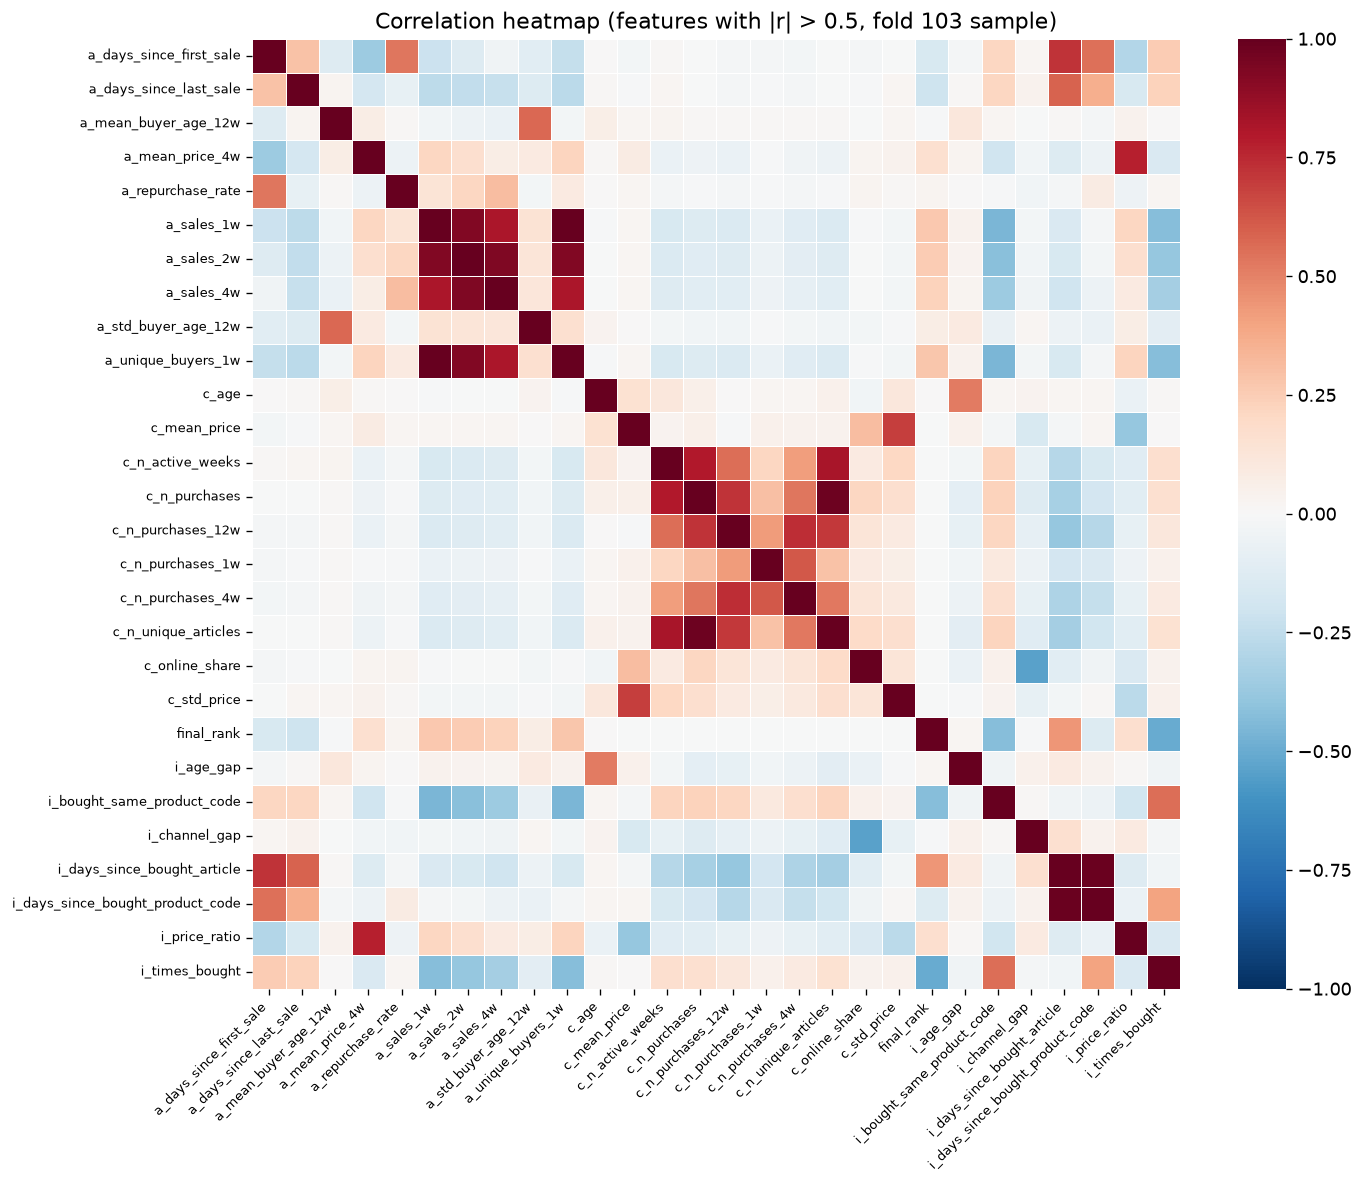

Saved feat03_correlation_heatmap.png


In [10]:
# Heatmap for features with at least one |r| > 0.5
active = set()
for c1 in numeric_feats:
    for c2 in numeric_feats:
        if c1 != c2 and abs(corr.loc[c1, c2]) > 0.5:
            active.add(c1); active.add(c2)
active = sorted(active)[:28]

if active:
    sub_corr = corr.loc[active, active]
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(sub_corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.3, annot=False)
    ax.set_title('Correlation heatmap (features with |r| > 0.5, fold 103 sample)')
    plt.xticks(fontsize=8, rotation=45, ha='right')
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'feat03_correlation_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved feat03_correlation_heatmap.png')

**Observation:** The temporal sales windows (`a_sales_1w`, `a_sales_2w`, `a_sales_4w`) are highly correlated (r ≈ 0.8–0.95) since each window subsumes the shorter ones. Popularity source scores (`popularity_last_week_score`, `popularity_decayed_score`) correlate (r ≈ 0.8), consistent with their Jaccard overlap of 0.54 (see Section 3 of notebook 02). **Implication:** LightGBM trees are insensitive to multicollinearity. However, dropping `a_sales_2w` (fully captured by `a_sales_1w` + `a_sales_4w`) is worth testing in Session 4 for model simplification.

## 8. Stability — Population Stability Index (PSI, fold 100 vs fold 103)

In [11]:
with open(REPORTS_DIR / 'psi_results.json') as f:
    psi_data = json.load(f)
psi_rows = psi_data['psi_fold100_vs_fold103']
df_psi = pl.DataFrame(psi_rows).sort('psi', descending=True)
n_flagged = int((df_psi['psi'] > 0.2).sum())
print(f'Features with PSI > 0.2 (instability flag): {n_flagged} of {len(df_psi)}')
print()
print(df_psi.head(15).to_pandas().to_string(index=False))

Features with PSI > 0.2 (instability flag): 11 of 65

                   feature       group    psi
  popularity_decayed_score   candidate 4.1879
popularity_last_week_score   candidate 1.5610
    a_price_vs_own_history     article 1.4262
           a_mean_price_4w     article 0.5933
     segment_popular_score   candidate 0.5257
   a_days_since_first_sale     article 0.3188
         a_product_type_no     article 0.3058
           a_department_no     article 0.3031
        a_unique_buyers_1w     article 0.2815
                a_sales_1w     article 0.2411
      a_garment_group_name     article 0.2102
      a_product_group_name     article 0.1888
             i_price_ratio interaction 0.1736
                a_sales_2w     article 0.1650
             a_trend_ratio     article 0.1422


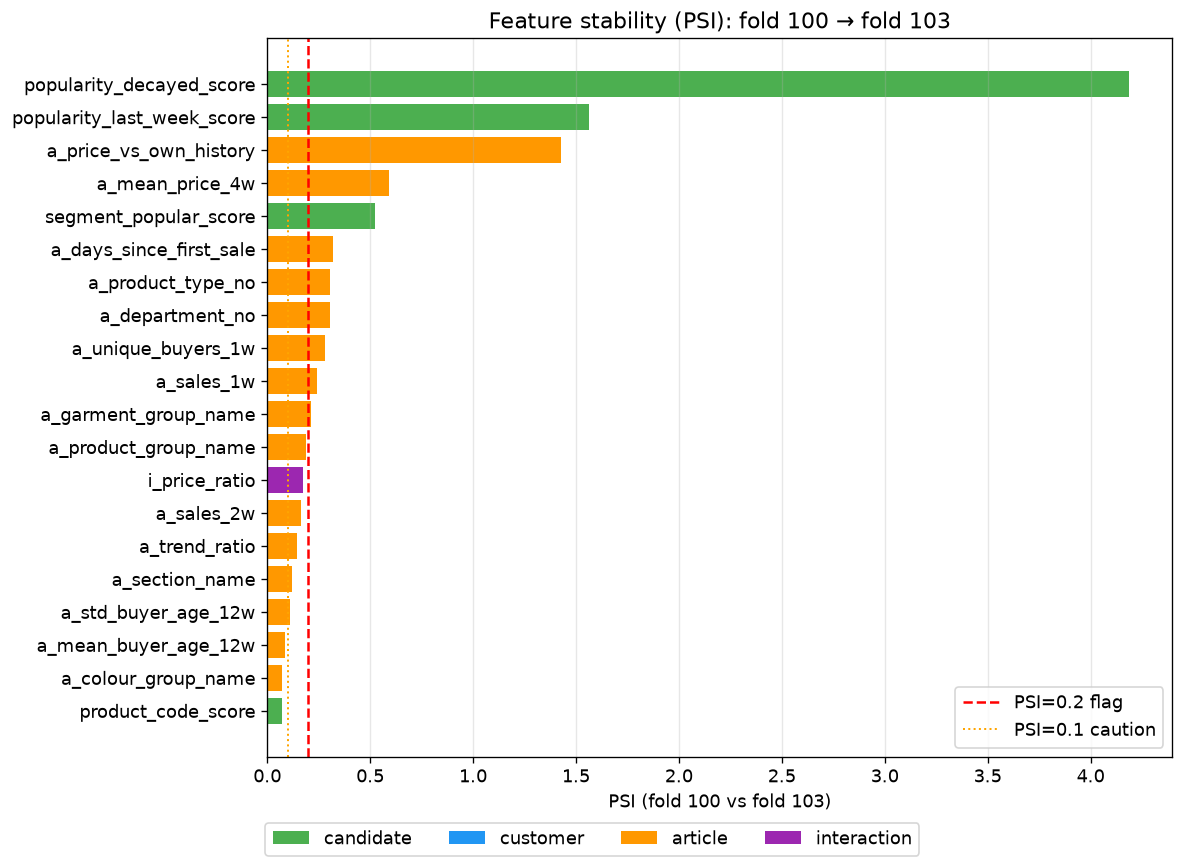

Saved feat04_psi.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
top_psi = df_psi.head(20).to_dicts()
bar_cols = [colors.get(r['group'], '#888') for r in top_psi[::-1]]
ax.barh([r['feature'] for r in top_psi[::-1]], [r['psi'] for r in top_psi[::-1]], color=bar_cols)
ax.axvline(0.2, color='red', ls='--', lw=1.5, label='PSI=0.2 flag')
ax.axvline(0.1, color='orange', ls=':', lw=1.2, label='PSI=0.1 caution')
ax.set_xlabel('PSI (fold 100 vs fold 103)')
ax.set_title('Feature stability (PSI): fold 100 → fold 103')
ax.legend()
ax.grid(axis='x', alpha=0.3)
fig.legend(handles=[Patch(facecolor=v, label=k) for k, v in colors.items()],
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig(FIG_DIR / 'feat04_psi.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved feat04_psi.png')

**Observation:** Popularity scores (`popularity_decayed_score` PSI=4.19, `popularity_last_week_score` PSI=1.56) and price-derived features (`a_price_vs_own_history` PSI=1.43, `a_mean_price_4w` PSI=0.59) show high PSI. **Important caveat:** popularity scores are raw transaction counts that scale with weekly sales volume (e.g., summer sale weeks have 3× the volume of quiet weeks), so PSI captures both genuine rank changes AND week-to-week scale variation. This PSI does not indicate a data quality problem. **Implication for Session 4:** Use rank-based versions of popularity features (`popularity_last_week_rank`, `popularity_decayed_rank`) instead of raw scores — they are scale-invariant across weeks and show much lower PSI. This is recommended for Session 4 but features are not changed now.

## 9. Summary and implications for Session 4

### Key findings

| Feature group | Count | Strongest signals | PSI concern |
|---|---|---|---|
| Candidate | 20 | `final_rank` (MAP@12=0.025), `repurchase_rank` (0.024) | Popularity scores (high PSI, use rank instead) |
| Customer | 16 | All have ~0 univariate MAP@12 (constant per customer) | Cold-start: 7-8% null |
| Article | 20 | `a_sales_1w`, `a_days_since_last_sale`, `a_censored_flag` | `a_mean_price_4w`, `a_price_vs_own_history` |
| Interaction | 9 | `i_days_since_bought_article` (MAP@12=0.024, same signal as repurchase), `i_days_since_bought_product_code` (0.017) | Low PSI |

All customers reach the 200-candidate budget. Peak RSS = 5.4 GB (fits on 16 GB machine).

### Session 4 recommended approach
1. **LightGBM LambdaRank**: group by `customer_idx`, `ndcg_eval_at=12`, train on folds 100–102
2. **Feature engineering**: all 65 features; consider dropping `a_sales_2w` (high correlation)
3. **Evaluation**: MAP@12 and NDCG@12 on fold 103; compare to heuristic MAP@12 = 0.024675 and Baseline B = 0.024201
4. **SHAP**: verify repurchase features dominate as univariate signal suggests
5. **Cold-start**: test LightGBM default-bin handling vs. a zero-fill strategy for null customer features

### Open questions
- Will LightGBM's ability to combine features across groups outperform the univariate heuristic significantly?
- Can the ranker close even 10% of the gap to oracle MAP@12 (0.200)?
- Which features contribute most to overfitting across folds?
